# Preliminari

In [ ]:
import json
import copy
import pandas as pd
import numpy as np
import os
import seaborn as sns
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

In [27]:
plt.style.use('ggplot')

In [2]:
RESULTS_FILE_NAME = "data_luca_predictions_2-llama-3.2-3B-FT-v1.jsonl"
TEST_FILE_NAME = "data_luca_test-v1.jsonl"

# Carica dati

In [3]:
# Carichiamo i nostri file JSON
results_path = Path('../results/' + RESULTS_FILE_NAME)
test_path = Path('../data/ft-dataset/' + TEST_FILE_NAME)

with open(results_path, "r", encoding="utf-8") as f:
    results = [json.loads(line) for line in f]
    
with open(test_path, "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

print(f"{len(results) = }")
print(f"{len(test_data) = }")

len(results) = 35
len(test_data) = 35


In [5]:
print(f"{results[0] = }")
print(f"{type(results[0]) = }")
print(f"{type(results[0]['prediction']) = }")

print(f"{test_data[0] = }")
print(f"{type(test_data[0]) = }")
print(f"{type(test_data[0]['messages'][2]['content']) = }")

results[0] = {'model': 'iltramont/llama-3.2-3B-FT-v1', 'temperature': 0.8, 'min_p': 0.1, 'prediction': '{"morfologia": "solido_polipoide", "spessore_parietale": null, "estensione_cranio_caudale": 50.0, "distanza_oai": 60.0, "posizione": "medio", "carcinosi_peritoneale": null, "lesioni_ossee": null, "riflessione_peritoneale_anteriore": null, "infiltrazione_tessuto_adiposo": "si_5mm_plus", "infiltrazione_sfinteri": "no", "infiltrazione_organi_extra": "no", "coinvolgimento_riflessione_peritoneale": "no", "coinvolgimento_fascia_mesorettale": "no", "linfonodi_sospetti": 4.0, "linfonodi_mesorettali": true, "linfonodi_rettali_superiori": false, "linfonodi_mesenterici_inferiori": false, "linfonodi_iliaci_interni": false, "linfonodi_otturatori": false, "linfonodi_sacrali": false, "linfonodi_inguinali_sotto_dentata": false, "linfonodi_inguinali": false, "linfonodi_iliaci_esterni": false, "linfonodi_iliaci_comuni": false, "linfonodi_paraortici": false, "linfonodi_altri": false, "depositi_tumorali

# Metriche

## preliminari metriche

In [6]:
LABELS = list(test_data[0]['messages'][2]['content'].keys())
for i, l in enumerate(LABELS):
    print(f"{l:40}", end='')
    if i % 3 == 2:
        print()
    
print(f'\n\nNumero labels: {len(LABELS)}')

morfologia                              spessore_parietale                      estensione_cranio_caudale               
distanza_oai                            posizione                               carcinosi_peritoneale                   
lesioni_ossee                           riflessione_peritoneale_anteriore       infiltrazione_tessuto_adiposo           
infiltrazione_sfinteri                  infiltrazione_organi_extra              coinvolgimento_riflessione_peritoneale  
coinvolgimento_fascia_mesorettale       linfonodi_sospetti                      linfonodi_mesorettali                   
linfonodi_rettali_superiori             linfonodi_mesenterici_inferiori         linfonodi_iliaci_interni                
linfonodi_otturatori                    linfonodi_sacrali                       linfonodi_inguinali_sotto_dentata       
linfonodi_inguinali                     linfonodi_iliaci_esterni                linfonodi_iliaci_comuni                 
linfonodi_paraortici            

## Corretteza forma output

In [ ]:
def json_valido(json_string) -> bool:
    try:
        json.loads(json_string)
        return True
    except ValueError:
        return False
    
    
def json_con_tutte_le_labels(prediction) -> bool:
    if json_valido(prediction):
        chiavi_prediction = set(json.loads(prediction).keys())
        return chiavi_prediction == set(LABELS)
    else:
        return False        
    

def aggiungi_chiavi_mancanti(prediction_dict: dict) -> None:
    for k in LABELS:
        if k not in set(prediction_dict.keys()):
            prediction_dict[k] = None         

In [8]:
corretti = 0
for i, result in enumerate(results):
    if not json_valido(result['prediction']):
        print(f"JSON {i} non valido: {result['prediction']}")
    else:
        corretti += 1
print(f"JSON validi: {corretti}/{len(results)} ({corretti/len(results)*100:.2f}%)")

denominatore = corretti
numeratore = 0
for i, result in enumerate(results):
    if json_valido(result['prediction']):
        prediction_dict = json.loads(result['prediction'])  
        if not set(prediction_dict.keys()) == set(LABELS):
            print(f"prediction {i} con chiavi mancanti")
        numeratore += 1
        
print(f"JSON validi con tutte le labels: {numeratore}/{denominatore} ({numeratore/denominatore*100:.2f}%)")

JSON validi: 35/35 (100.00%)
JSON validi con tutte le labels: 35/35 (100.00%)


## Correttezza singola prediction

In [9]:
def visualizza_prediction(prediction_dict: dict, target: dict) -> pd.DataFrame:
    # Valorizza chiavi mancanti come nulle
    aggiungi_chiavi_mancanti(prediction_dict)
    rows = []
    for k, t in target.items():
        p = prediction_dict[k]
        rows.append((k, t, p))
    df = pd.DataFrame(rows, columns=['LABELS', 'TRUTH', 'PREDICTION'])
    return df


def single_score(prediction: str, target: dict, verbose: int = 0) -> float:
    if not json_valido(prediction):
        return 0.0
    prediction_dict = json.loads(prediction)
    # Valorizza chiavi mancanti come nulle
    aggiungi_chiavi_mancanti(prediction_dict)
    correct = 0
    total = 0
    for k, t in target.items():
        total += 1
        p = prediction_dict[k]
        points = 0
        if t is None:
            if p is None:
                points = 1
        else:
            if p is not None and p == t:
                points += 1
        correct += points
    if verbose >= 2:
        print(visualizza_prediction(prediction_dict, target))
    if verbose >= 1:
        print(f"Correct: {correct}/{total} ({correct/total*100:.2f}%)")
    return correct / total

In [107]:
scores = []
for i, r in enumerate(results):
    scores.append(single_score(r['prediction'], test_data[i]['messages'][2]['content']))    

scores.sort(reverse=True)

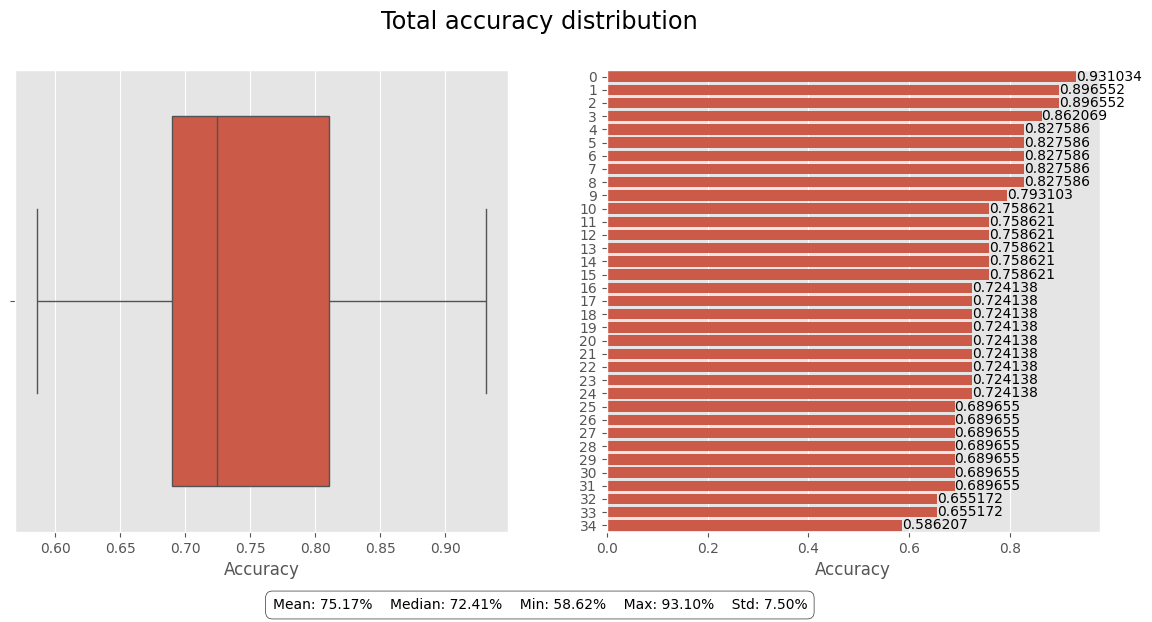

In [120]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle('Total accuracy distribution', fontsize='xx-large')

sns.boxplot(data=scores, ax=ax1, orient='h')
ax1.set_xlabel('Accuracy', fontsize='large')
text =  f'Mean: {100*np.mean(scores):.2f}%' \
        f'    Median: {100*np.median(scores):.2f}%' \
        f'    Min: {100*np.min(scores):.2f}%' \
        f'    Max: {100*np.max(scores):.2f}%' \
        f'    Std: {100*np.std(scores):.2f}%'

sns.barplot(y=np.arange(len(scores)), x=scores, ax=ax2, orient='h')
ax2.bar_label(ax2.containers[0])
ax2.set_xlabel('Accuracy', fontsize='large')


fig.text(0.5, 0, text, bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='black'), ha='center', va='top')
plt.show()

### Test

In [12]:
print(single_score(results[0]['prediction'], test_data[0]['messages'][2]['content'], verbose=2))

                                    LABELS           TRUTH        PREDICTION
0                               morfologia  solido_anulare  solido_polipoide
1                       spessore_parietale            None              None
2                estensione_cranio_caudale            50.0              50.0
3                             distanza_oai            60.0              60.0
4                                posizione           medio             medio
5                    carcinosi_peritoneale              no              None
6                            lesioni_ossee              no              None
7        riflessione_peritoneale_anteriore            None              None
8            infiltrazione_tessuto_adiposo     si_5mm_plus       si_5mm_plus
9                   infiltrazione_sfinteri              no                no
10              infiltrazione_organi_extra              no                no
11  coinvolgimento_riflessione_peritoneale              si                no

# Analisi singole labels

In [ ]:
LABELS = list(test_data[0]['messages'][2]['content'].keys())

In [145]:
compare_dict = {
    'index': [],
    'real': [],
    'prediction': []
}

for i in range(len(results)):
    if json_valido(results[i]['prediction']):
        pred_dict = json.loads(results[i]['prediction'])
        aggiungi_chiavi_mancanti(pred_dict)
        compare_dict['index'].append(i)
        compare_dict['real'].append(test_data[i]['messages'][2]['content'])
        compare_dict['prediction'].append(pred_dict)

In [150]:
pred_labels_dict = dict()
for label in LABELS:
    pred_labels_dict[label] = {
        'index': [],
        'real': [],
        'prediction': []
    }

for i in compare_dict['index']:
    for label in LABELS:
        pred_labels_dict[label]['real'].append(compare_dict['real'][i][label])
        pred_labels_dict[label]['prediction'].append(compare_dict['prediction'][i][label])    
        pred_labels_dict[label]['index'].append(i)    

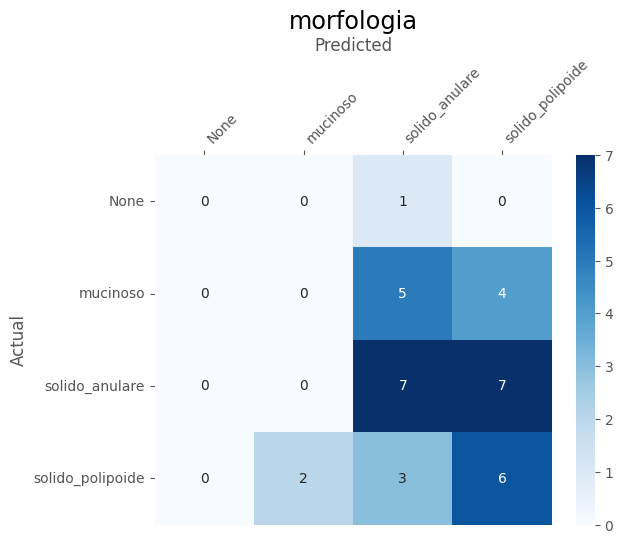

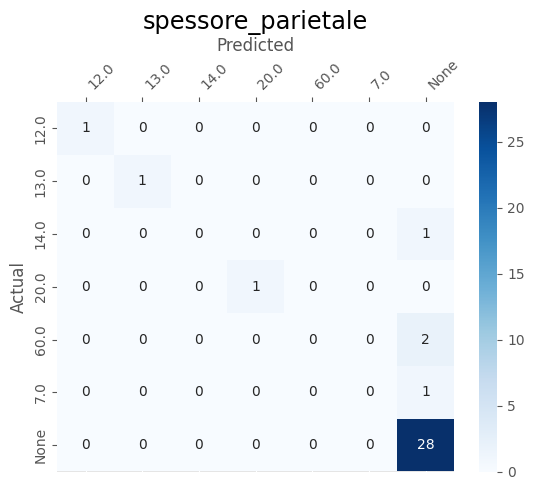

c:\Users\lucat\VSCodeProjects\PRIN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


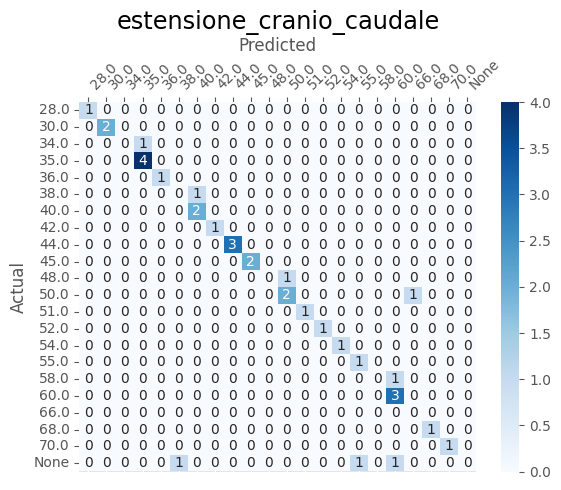

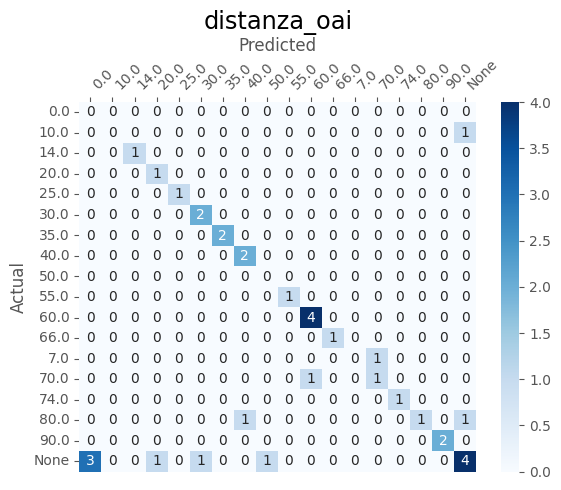

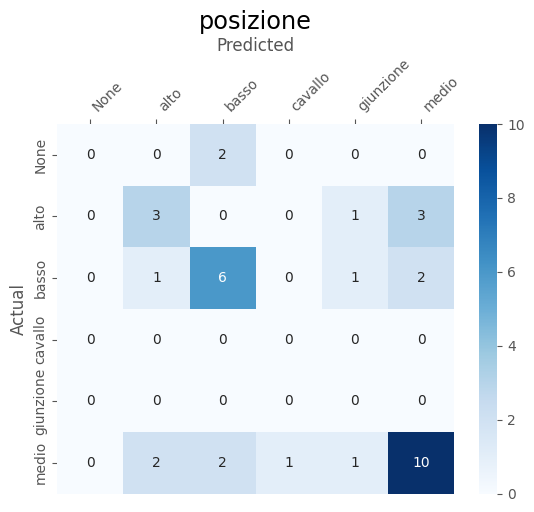

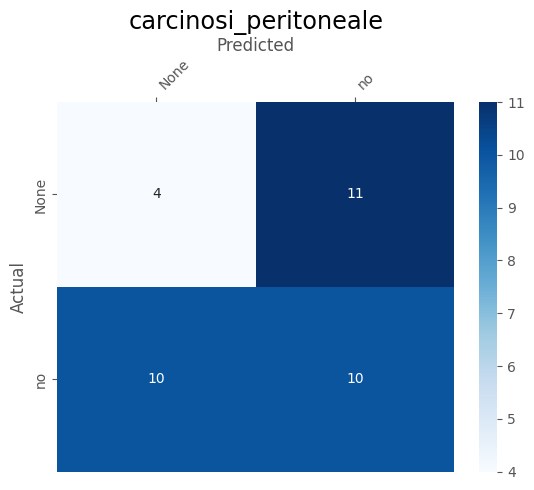

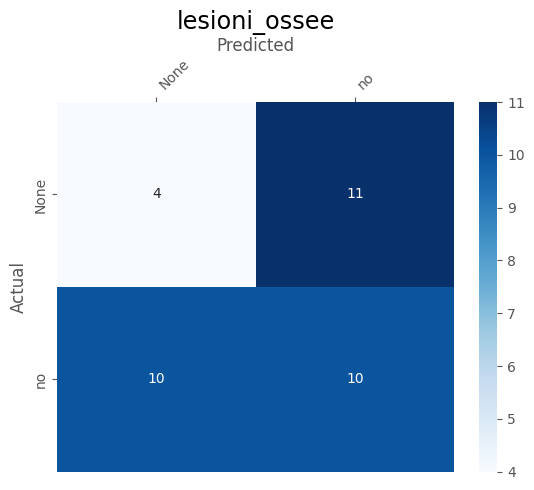

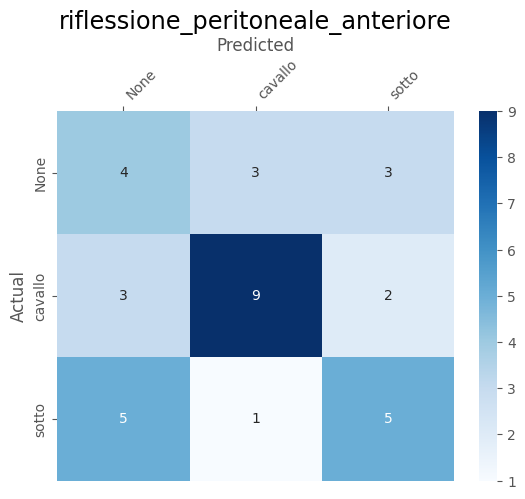

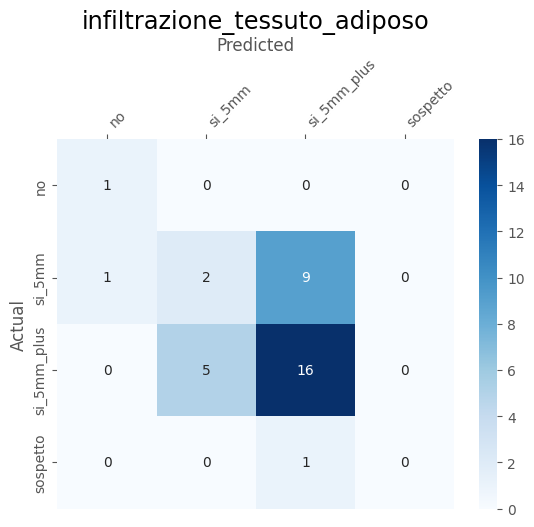

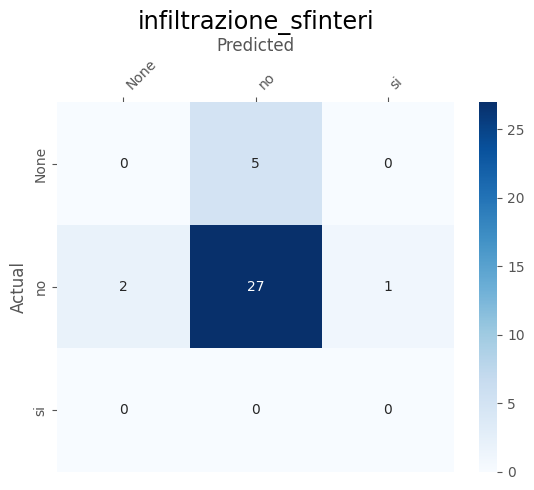

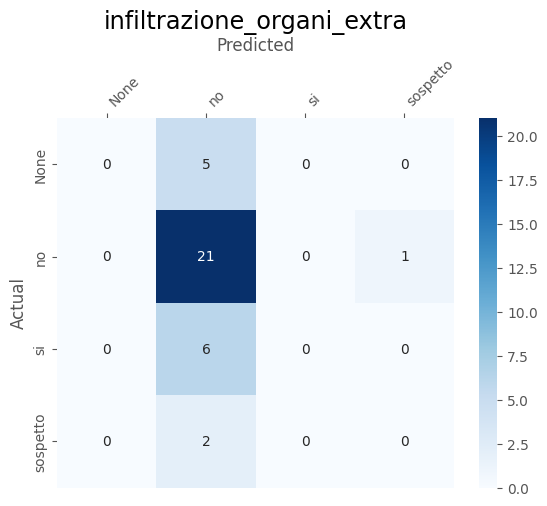

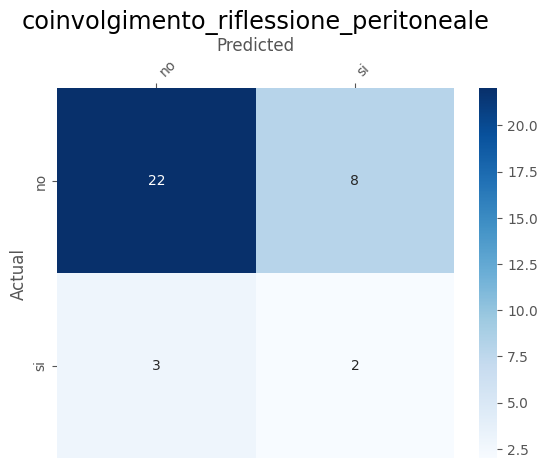

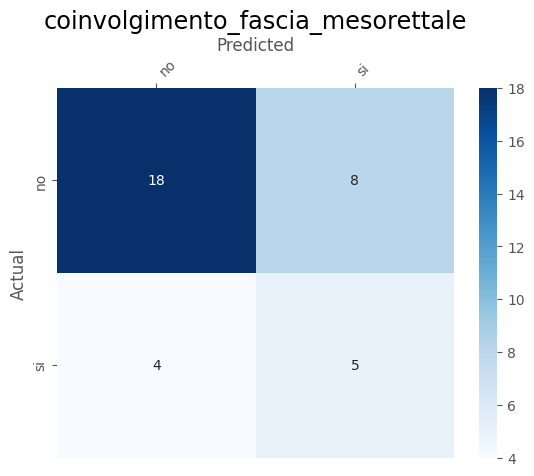

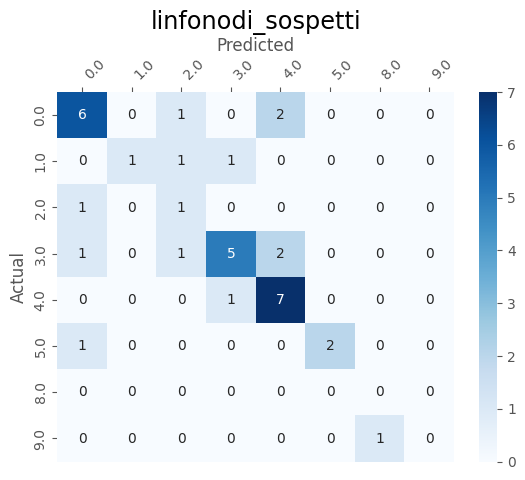

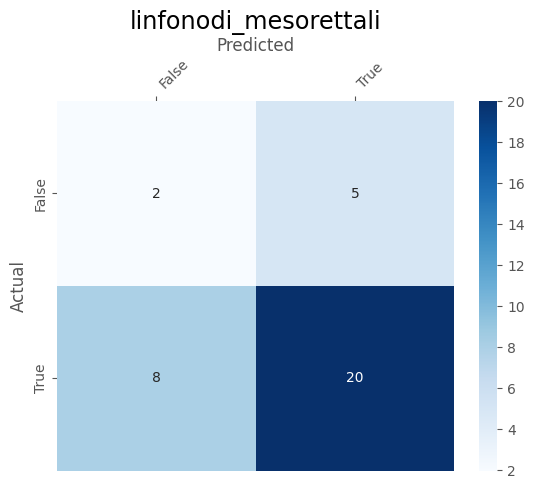

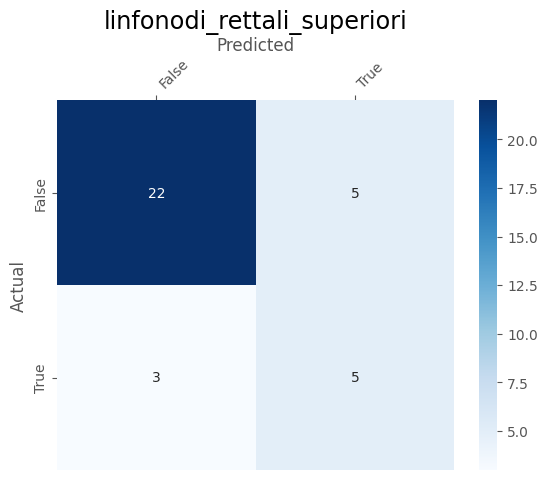

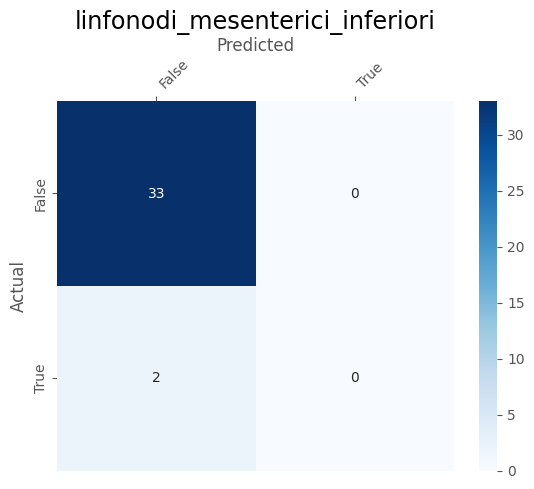

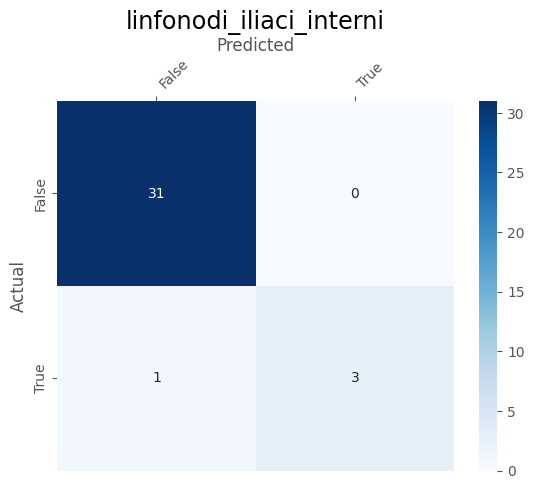

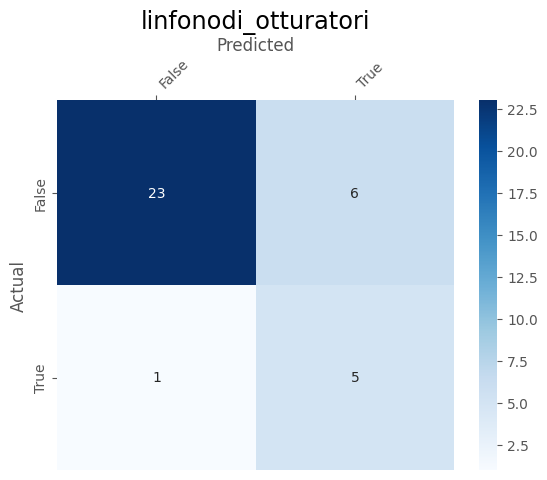

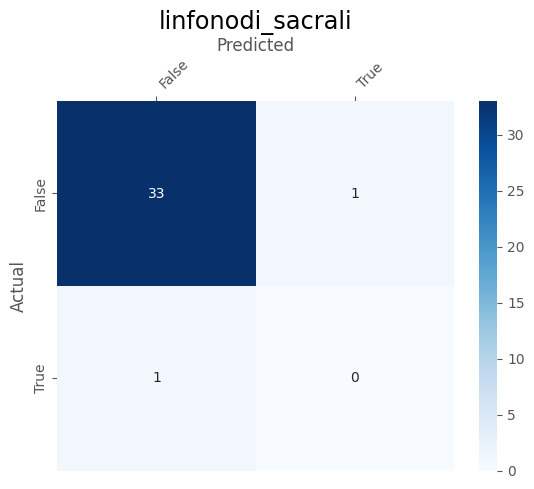

c:\Users\lucat\VSCodeProjects\PRIN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


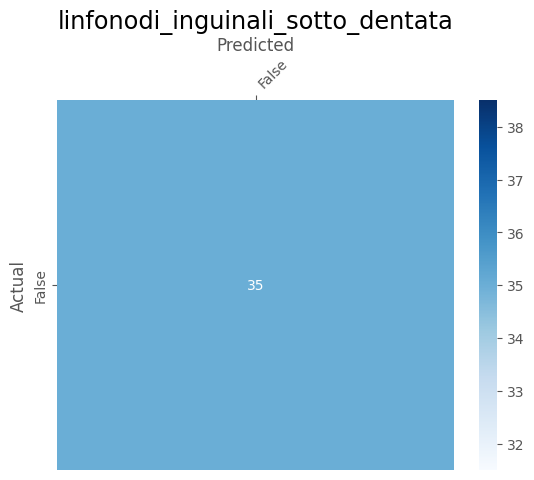

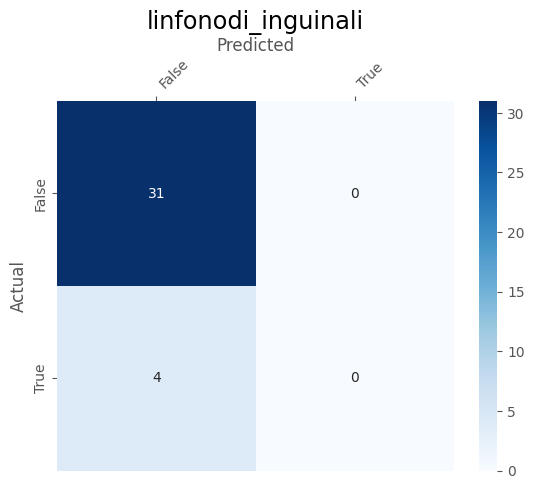

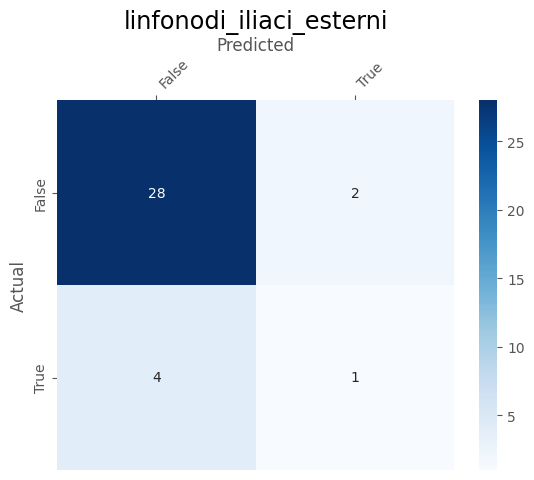

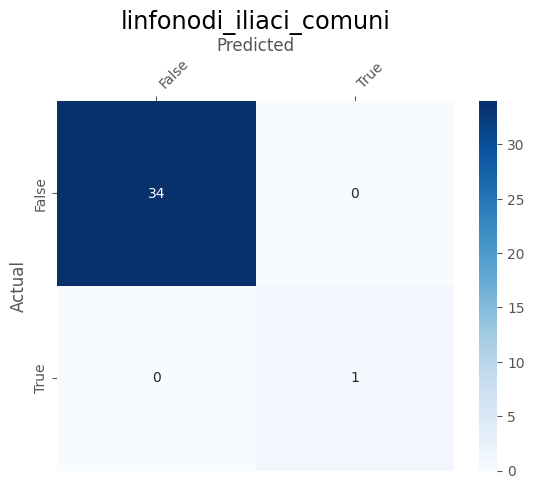

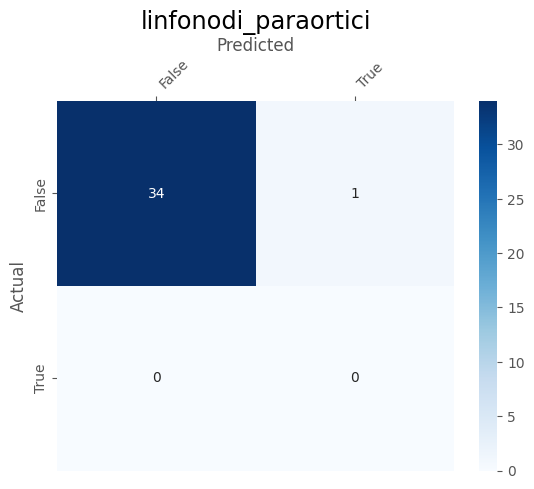

c:\Users\lucat\VSCodeProjects\PRIN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


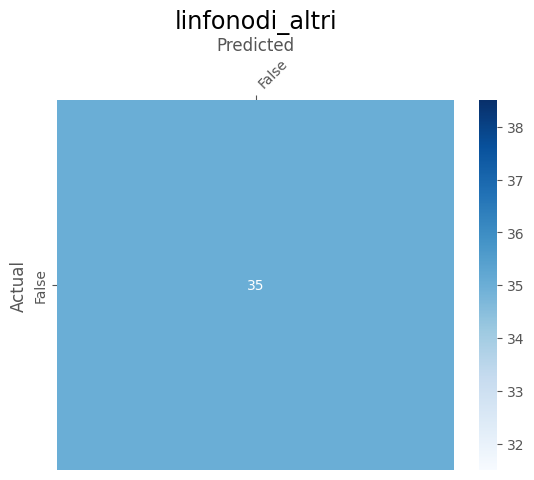

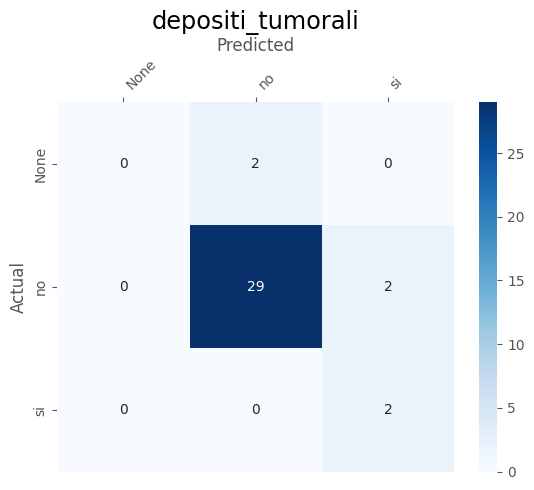

c:\Users\lucat\VSCodeProjects\PRIN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


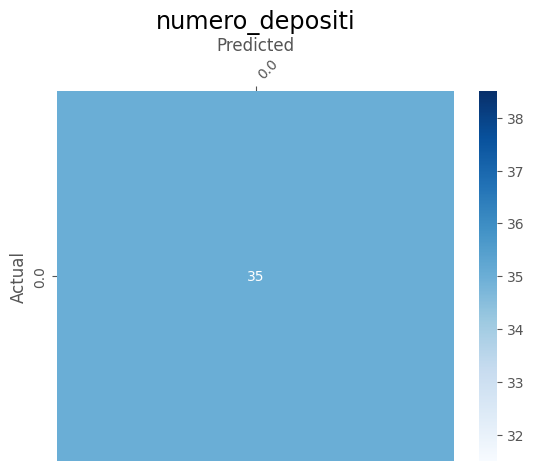

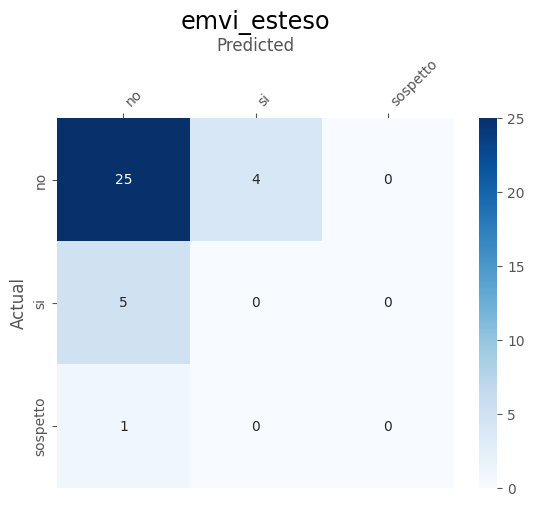

In [192]:
for label in LABELS:
    y_true = [str(x) for x in pred_labels_dict[label]['real']]
    y_pred = [str(x) for x in pred_labels_dict[label]['prediction']]

    fig, ax = plt.subplots()
    class_labels = np.unique(np.concatenate([y_true, y_pred]))

    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(label, fontsize='xx-large')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')  # anche il titolo dell'asse X va sopra

    plt.xticks(rotation=45, ha='left')
    plt.show()
